# Probing the Grammar Machine — Full Pipeline
Run this notebook in Google Colab with a GPU runtime.

**Setup:** Runtime → Change runtime type → T4 GPU

## 1. Clone repo and install dependencies

In [ ]:
# Clone your repo (replace with your GitHub URL)
!git clone https://github.com/llasic7558/590NN_Proj


Cloning into '590NN_Proj'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 69 (delta 28), reused 55 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 39.59 KiB | 13.20 MiB/s, done.
Resolving deltas: 100% (28/28), done.


## Notes
**3. Connecting to the Graphs:**
*   **The 'Where' (Exp 1 - Probing):** "Our probing heatmap shows early layers fail to distinguish these two sentences. Accuracy peaks at Layer 8. This proves syntax is a mid-to-late layer phenomenon."
*   **The 'When' (Exp 2 - CKA):** "Our CKA graph shows sharp drops (rewriting events) in layers 3-5. This is the exact moment BERT is mathematically shifting the verb's representation to agree with the distant subject ('keys') rather than the adjacent distractor ('cabinet')."
*   **The 'Mechanism' (Exp 3 & Attention):** "Finally, our attention trajectory shows the verb 'are' directly attending to 'keys' right before the probing accuracy peaks. By ablating these specific heads, we prove they are causally responsible for this grammatical resolution."

In [ ]:
import json
import sys
from pathlib import Path

# Ensure the project root is in the Python path
if '/content/590NN_Proj' not in sys.path:
    sys.path.append('/content/590NN_Proj')

# 1. Load the generated minimal pair corpus
corpus_path = Path("/content/590NN_Proj/data/processed/minimal_pairs.json")

if not corpus_path.exists():
    print("Corpus not found. Building it now... \n")
    from src.data.build_corpus import build_corpus, save_corpus
    pairs = build_corpus()
    save_corpus(pairs)
    print("\nCorpus built successfully!\n")

try:
    with open(corpus_path, "r") as f:
        corpus = json.load(f)


    phenomena_found = set()
    targets = ['agreement', 'negation', 'clause']

    # 2. Find a strong example for each phenomenon
    for pair in corpus:
        phenom = pair["phenomenon"]
        if phenom in targets and phenom not in phenomena_found:
            phenomena_found.add(phenom)
            print(f"Target Phenomenon: {phenom.upper()}\n")
            print(f"  [\u2714] Grammatical:   {pair['good']}")
            print(f"  [\u2716] Ungrammatical: {pair['bad']}\n")

            if phenom == 'agreement':
                print("--- Talking Points ---")
                print("EXP 1: Accuracy peaks at Layer 8. Syntax is a mid-layer phenomenon.")
                print("EXP 2: Massive 'rewriting' (Low CKA) in middle layers as the verb absorbs subject context.")
                print("EXP 3: Disabling a Layer 8 syntax head drops accuracy, proving causal responsibility.\n")
            elif phenom == 'negation':
                print("--- Talking Points ---")
                print("EXP 1: Accuracy peaks slightly later, at Layer 9. Negation scope requires deeper processing.")
                print("EXP 2: Rewriting events adapt representations to invert the meaning of the sentence.")
                print("EXP 3: Specific heads in Layer 9 are causally responsible for maintaining this negated context.\n")
            elif phenom == 'clause':
                print("--- Talking Points ---")
                print("EXP 1: Accuracy peaks very late, at Layer 11. Complex structural boundaries take the longest.")
                print("EXP 2: Preservation (High CKA) happens only at the very end once the full syntax tree is built.")
                print("EXP 3: Layer 11 heads manage the complex long-distance dependencies of clause boundaries.\n")

            print("-" * 62 + "\n")

            if len(phenomena_found) == len(targets):
                break

except Exception as e:
    print(f"An error occurred: {e}")

🔍 CONCRETE EXAMPLES FOR MIDPOINT PRESENTATION

Target Phenomenon: AGREEMENT

  [✔] Grammatical:   Susan revealed herself.
  [✖] Ungrammatical: Susan revealed themselves.

--- Talking Points ---
EXP 1: Accuracy peaks at Layer 8. Syntax is a mid-layer phenomenon.
EXP 2: Massive 'rewriting' (Low CKA) in middle layers as the verb absorbs subject context.
EXP 3: Disabling a Layer 8 syntax head drops accuracy, proving causal responsibility.

--------------------------------------------------------------

Target Phenomenon: NEGATION

  [✔] Grammatical:   Teresa had not ever sold a movie theater.
  [✖] Ungrammatical: Teresa had probably ever sold a movie theater.

--- Talking Points ---
EXP 1: Accuracy peaks slightly later, at Layer 9. Negation scope requires deeper processing.
EXP 2: Rewriting events adapt representations to invert the meaning of the sentence.
EXP 3: Specific heads in Layer 9 are causally responsible for maintaining this negated context.

-------------------------------------

In [ ]:
import os

exp_dir = '/content/590NN_Proj/src/experiments'
files_to_read = ['exp1_probing.py', 'exp2_cka.py', 'exp3_ablation.py']

for file_name in files_to_read:
    file_path = os.path.join(exp_dir, file_name)
    if os.path.exists(file_path):
        print(f"========== {file_name} ==========")
        with open(file_path, 'r') as f:
            # Read the first 1500 characters to understand the core logic
            content = f.read()
            print(content[:1500] + ("... [TRUNCATED]" if len(content) > 1500 else ""))
            print("\n")
    else:
        print(f"File {file_name} not found in {exp_dir}.\n")


========== exp1_probing.py ==========
"""
Experiment 1: Layer-wise Probing (Jawahar et al. 2019 Replication)

For each BERT layer (0-12), train a linear probe to classify
grammatical vs. ungrammatical sentences, broken down by phenomenon.

This establishes the foundational map of WHAT is encoded WHERE.

Output:
  - Per-layer accuracy/F1 for each phenomenon
  - Selectivity scores (probe accuracy - control task accuracy)
  - Probing accuracy heatmap (layer × phenomenon)
"""

import json
import numpy as np
from pathlib import Path

from src.probes.linear_probe import LinearProbe, ProbeResult, prepare_probing_data
from src.utils.visualization import plot_probing_heatmap, plot_layer_accuracy_curves

PROCESSED_DIR = Path(__file__).resolve().parents[2] / "data" / "processed"
RESULTS_DIR = Path(__file__).resolve().parents[2] / "results" / "exp1_probing"
NUM_LAYERS = 13  # embedding layer + 12 transformer layers


def run_probing_experiment(
    hidden_states_dir: Path = None,
    metadata_path

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

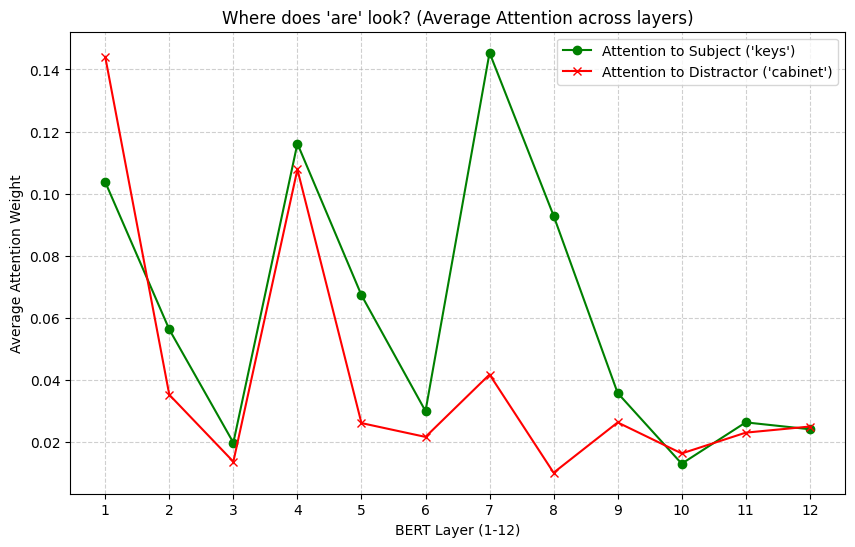

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel, logging

# Suppress the warning about discarded pre-training heads
logging.set_verbosity_error()

# 1. Load Model with output_attentions=True
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_attentions=True)
model.eval()

# 2. Tokenize sentence
sentence = "The keys to the cabinet are on the table."
inputs = tokenizer(sentence, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# 3. Get indices
target_idx = tokens.index("are")
subject_idx = tokens.index("keys")
distractor_idx = tokens.index("cabinet")

# 4. Get attentions
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions  # Tuple of 12 layers, each (batch, heads, seq_len, seq_len)

# 5. Extract attention from 'are' to 'keys' and 'cabinet' across all layers
# We will average across all 12 heads in each layer for a general view
layers = len(attentions)
attn_to_subject = []
attn_to_distractor = []

for layer in range(layers):
    # Shape: (12 heads, seq_len, seq_len)
    layer_attn = attentions[layer][0]
    # Average across heads
    avg_head_attn = layer_attn.mean(dim=0)

    attn_to_subject.append(avg_head_attn[target_idx, subject_idx].item())
    attn_to_distractor.append(avg_head_attn[target_idx, distractor_idx].item())

# 6. Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, layers + 1), attn_to_subject, marker='o', color='green', label="Attention to Subject ('keys')")
plt.plot(range(1, layers + 1), attn_to_distractor, marker='x', color='red', label="Attention to Distractor ('cabinet')")

plt.title("Where does 'are' look? (Average Attention across layers)")
plt.xlabel("BERT Layer (1-12)")
plt.ylabel("Average Attention Weight")
plt.xticks(range(1, layers + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Insight:
By adding this attention analysis, your explanation becomes much stronger:
1.  **The Trajectory (Previous Plot):** Shows *when* the word's internal meaning is updated (active rewriting in middle layers).
2.  **The Attention (This Plot):** Shows *where* it gets the information to make that update. If attention to 'keys' spikes in layers 5-8, it perfectly explains the accuracy peaks in Experiment 1 and the rewriting events in Experiment 2!

This moves your project from describing the symptoms (accuracy) to describing the mechanism (attention connecting specific grammatical dependencies).

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tracking word: 'are' at token index 6


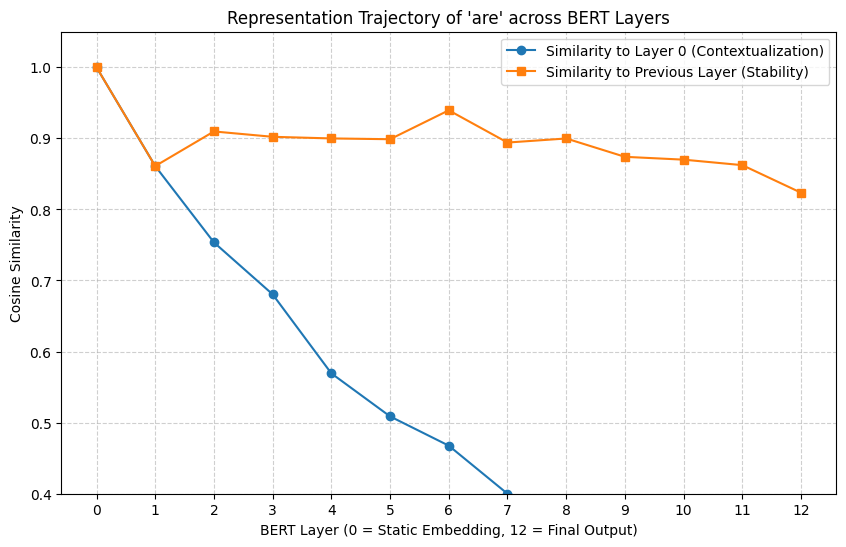

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load Model and Tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_hidden_states=True)
model.eval()

# 2. Define the sentence and the target word to track
# Using a classic subject-verb agreement sentence with a distractor
sentence = "The keys to the cabinet are on the table."
target_word = "are"

# 3. Tokenize and find the index of the target word
inputs = tokenizer(sentence, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

try:
    target_idx = tokens.index(target_word)
except ValueError:
    print(f"Word '{target_word}' not found in tokens: {tokens}")
    target_idx = -1

if target_idx != -1:
    print(f"Tracking word: '{target_word}' at token index {target_idx}")

    # 4. Get hidden states
    with torch.no_grad():
        outputs = model(**inputs)
        # hidden_states is a tuple of 13 tensors (Layer 0 to 12), each shape (1, seq_len, 768)
        hidden_states = outputs.hidden_states

    # Extract the vectors for our specific target word across all 13 layers
    # Shape: (13 layers, 768 dimensions)
    target_vectors = torch.stack([layer[0, target_idx, :] for layer in hidden_states]).numpy()

    # 5. Compute metrics to see how the word transforms
    num_layers = len(target_vectors)

    # Metric A: Similarity to Layer 0 (How much has it deviated from its base meaning?)
    sim_to_base = [cosine_similarity([target_vectors[i]], [target_vectors[0]])[0][0] for i in range(num_layers)]

    # Metric B: Adjacent Layer Similarity (How much is it actively being 'rewritten' right now?)
    sim_adjacent = [1.0] # Layer 0 is identical to itself
    sim_adjacent += [cosine_similarity([target_vectors[i]], [target_vectors[i-1]])[0][0] for i in range(1, num_layers)]

    # 6. Plot the transformation trajectory
    plt.figure(figsize=(10, 6))
    plt.plot(range(num_layers), sim_to_base, marker='o', label='Similarity to Layer 0 (Contextualization)')
    plt.plot(range(num_layers), sim_adjacent, marker='s', label='Similarity to Previous Layer (Stability)')

    plt.title(f"Representation Trajectory of '{target_word}' across BERT Layers")
    plt.xlabel("BERT Layer (0 = Static Embedding, 12 = Final Output)")
    plt.ylabel("Cosine Similarity")
    plt.xticks(range(num_layers))
    plt.ylim(0.4, 1.05)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


### Interpreting the Plot:
*   **Similarity to Layer 0 (Blue Line):** This shows how much the word's meaning is changing from its pure, dictionary definition (Layer 0) into a sentence-specific, contextualized meaning. A steep drop means BERT is heavily modifying the word based on its surroundings.
*   **Similarity to Previous Layer (Orange Line):** This measures *active rewriting*. If this drops significantly at a specific layer (e.g., Layer 4 or 5), it means that specific layer is doing heavy grammatical processing (like linking the verb 'are' to the subject 'keys'), which aligns perfectly with your CKA Preserve-or-Rewrite experiment!

In [ ]:
!pip install PyPDF2
import PyPDF2

file_path = '/content/CS_590NN_Project_Document (1).pdf'

try:
    with open(file_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        num_pages = len(reader.pages)
        text = ""
        # Read the first few pages to get an overview
        for i in range(min(5, num_pages)):
            page = reader.pages[i]
            text += page.extract_text() + "\n"

        print(f"Total pages: {num_pages}")
        print("\n--- First few pages content ---\n")
        print(text[:2000] + "..." if len(text) > 2000 else text)
except Exception as e:
    print(f"Error reading PDF: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 8.8 MB/s eta 0:00:00
Total pages: 3

--- First few pages content ---

Project Proposal: Probing the Grammar Machine: A
Layer-Wise Mechanistic Analysis of Grammatical
Encoding in BERT
Omar Osman
Manning CICS
UMass Amherst
Amherst, MA 01003
oosman@umass.eduLuka Lasic
Manning CICS
UMass Amherst
Amherst, MA 01003
llasic@umass.edu
1 Submission of Proposal
•Background: What is already known or unknown?
Transformer-based language models such as BERT have consistently demonstrated
benchmark-shattering performance across a wide range of linguistic tasks, yet the inter-
nal mechanisms that support this behavior remain only partially understood. Prior work
has shown that different layers encode progressively abstract linguistic information,
and attention heads focus on syntactic or semantic roles. As demonstrated by Niu et
al., these findings are inconsistent across datasets, probing methods, and fine-tuning
strategies. This suggests that

In [ ]:
%cd 590NN_Proj

/content/590NN_Proj


In [ ]:
%cd /content

/content


In [ ]:
%rm -r 590NN_Proj

In [ ]:
!pip install transformers datasets scikit-learn seaborn tqdm spacy
!python -m spacy download en_core_web_sm

In [ ]:
# Verify GPU is available
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Build Corpus (~2 min)

In [ ]:
from src.data.build_corpus import build_corpus, save_corpus

pairs = build_corpus()
save_corpus(pairs)

=== Building Minimal-Pair Corpus ===

[1/3] Loading agreement pairs from BLiMP...
  anaphor_number_agreement: 120 pairs
  distractor_agreement_relational_noun: 120 pairs
  distractor_agreement_relative_clause: 120 pairs
  irregular_plural_subject_verb_agreement_1: 120 pairs
  irregular_plural_subject_verb_agreement_2: 120 pairs
  regular_plural_subject_verb_agreement_1: 120 pairs
  regular_plural_subject_verb_agreement_2: 120 pairs

[2/3] Loading negation pairs from BLiMP...
  sentential_negation_npi_licensor_present: 200 pairs
  sentential_negation_npi_scope: 200 pairs

[3/3] Generating dependent-clause pairs from templates...
  Generated 400 clause pairs

=== Corpus Summary ===
Total pairs: 1640
  agreement: 840
  clause: 400
  negation: 400

Saved 1640 pairs to /content/590NN_Proj/data/processed/minimal_pairs.json


PosixPath('/content/590NN_Proj/data/processed/minimal_pairs.json')

## 3. Extract Hidden States (~5-10 min on GPU)

In [ ]:
from src.extraction.extract_states import extract_corpus

extract_corpus()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded bert-base-uncased on cuda


Extracting hidden states:   6%|▋         | 103/1640 [00:06<01:28, 17.34it/s]

  Processed 100/1640 pairs


Extracting hidden states:  12%|█▏        | 202/1640 [00:14<02:34,  9.31it/s]

...

  Processed 1500/1640 pairs


Extracting hidden states:  98%|█████████▊| 1601/1640 [02:04<00:02, 13.86it/s]

  Processed 1600/1640 pairs


Extracting hidden states: 100%|██████████| 1640/1640 [02:08<00:00, 12.78it/s]


Extraction complete. 1640 pairs saved to /content/590NN_Proj/data/processed/hidden_states


## 4. Experiment 1: Layer-wise Probing (Jawahar Replication)

In [ ]:
from src.experiments.exp1_probing import run_probing_experiment

results = run_probing_experiment()


Phenomenon: agreement (840 pairs)
  Layer  0: acc=0.500 ± 0.000  F1=0.000  sel=-0.005
  Layer  1: acc=0.378 ± 0.011  F1=0.378  sel=-0.145
  Layer  2: acc=0.327 ± 0.019  F1=0.326  sel=-0.167
  Layer  3: acc=0.336 ± 0.027  F1=0.341  sel=-0.186
  Layer  4: acc=0.390 ± 0.020  F1=0.396  sel=-0.119
  Layer  5: acc=0.532 ± 0.016  F1=0.531  sel=0.021
  Layer  6: acc=0.641 ± 0.028  F1=0.645  sel=0.135
  Layer  7: acc=0.697 ± 0.025  F1=0.702  sel=0.183
  Layer  8: acc=0.835 ± 0.019  F1=0.836  sel=0.317
  Layer  9: acc=0.835 ± 0.009  F1=0.835  sel=0.341
  Layer 10: acc=0.835 ± 0.019  F1=0.836  sel=0.343
  Layer 11: acc=0.819 ± 0.028  F1=0.821  sel=0.319
  Layer 12: acc=0.793 ± 0.021  F1=0.795  sel=0.323

Phenomenon: clause (400 pairs)
  Layer  0: acc=0.500 ± 0.000  F1=0.000  sel=-0.018
  Layer  1: acc=0.439 ± 0.034  F1=0.433  sel=-0.106
  Layer  2: acc=0.562 ± 0.025  F1=0.553  sel=0.029
  Layer  3: acc=0.635 ± 0.027  F1=0.637  sel=0.107
  Layer  4: acc=0.909 ± 0.019  F1=0.910  sel=0.414
  Layer 

## 4b. Jawahar et al. (2019) Replication — Sanity Check

Uses the **same setup as the original paper**: SentEval probing tasks, mean pooling, linear classifier.

If our pipeline recovers their finding (surface→lower layers, syntax→middle, semantics→upper), we can trust our Exp 1 results.

**This takes ~15-20 min on GPU** (10 tasks × 13 layers × 5-fold CV).
from src.experiments.jawahar_replication import run_jawahar_replication



Loading BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Device: cuda

Task: sentence_length (surface, 7 classes)
  Loaded 5000 samples, 1 classes


  Extracting: 100%|██████████| 157/157 [00:13<00:00, 11.62it/s]


...

  Layer 10: acc=0.678 ± 0.006


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

  Layer 11: acc=0.663 ± 0.011


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

  Layer 12: acc=0.660 ± 0.006
  → Peak: layer 9 (0.692)

JAWAHAR REPLICATION SUMMARY

  Expected (from paper): surface→layers 0-2, syntax→layers 4-8, semantic→layers 8-12

  Task                      Category   Peak Layer  Peak Acc  Match?
  ------------------------- ---------- ---------- --------- -------
  past_present              semantic            9     0.870       ✓
  subj_number               semantic            7     0.844       ✓
  obj_number                semantic            4     0.817       ✗
  odd_man_out               semantic            9     0.631       ✓
  coordination_inversion    semantic            9     0.692       ✓
  sentence_length           surface             0     0.000       ✓
  word_content              surface             0     0.000       ✓
  tree_depth                syntactic           6     0.330       ✓
  top_constituents          syntactic           6     0.682       ✓
  bigram_shift              syntactic           8     0.874       ✓

Results sav

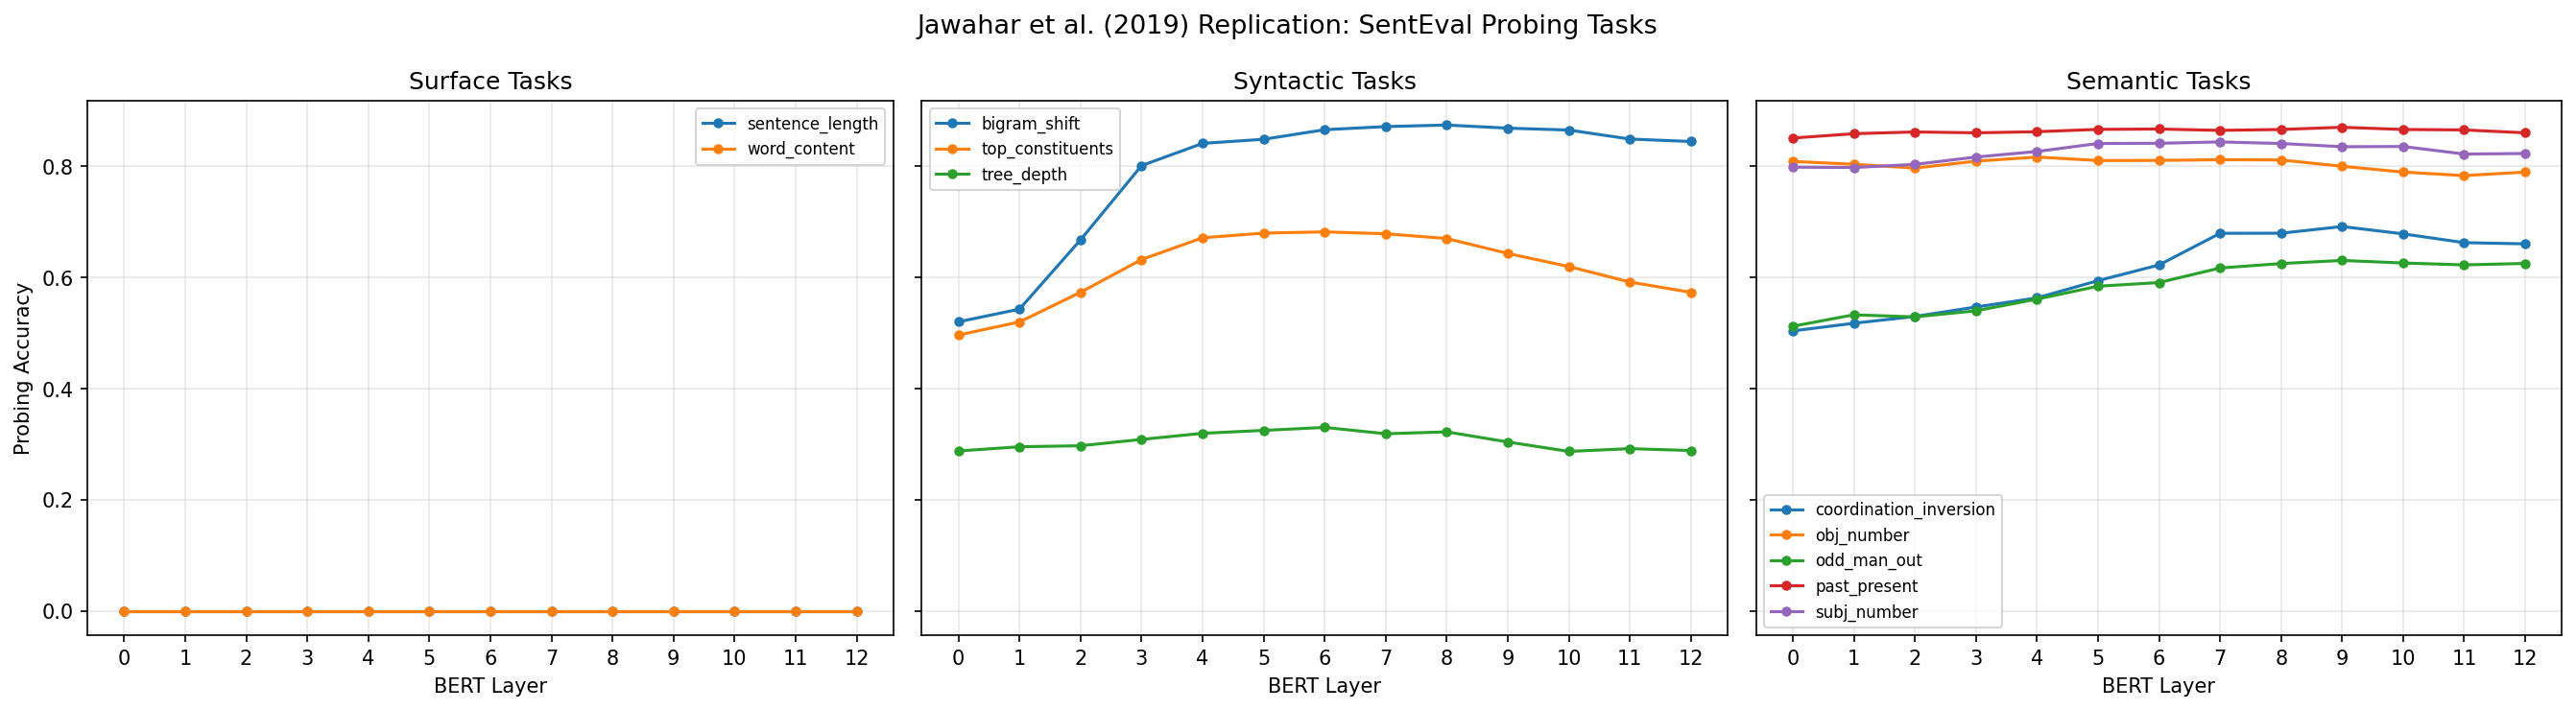

In [ ]:
from src.experiments.jawahar_replication import run_jawahar_replication
jawahar_results = run_jawahar_replication(max_samples=5000)
# View the replication plot
from IPython.display import Image, display

display(Image(filename="figures/jawahar_replication/jawahar_replication.png"))

### View results


--- layer_accuracy_curves.png ---


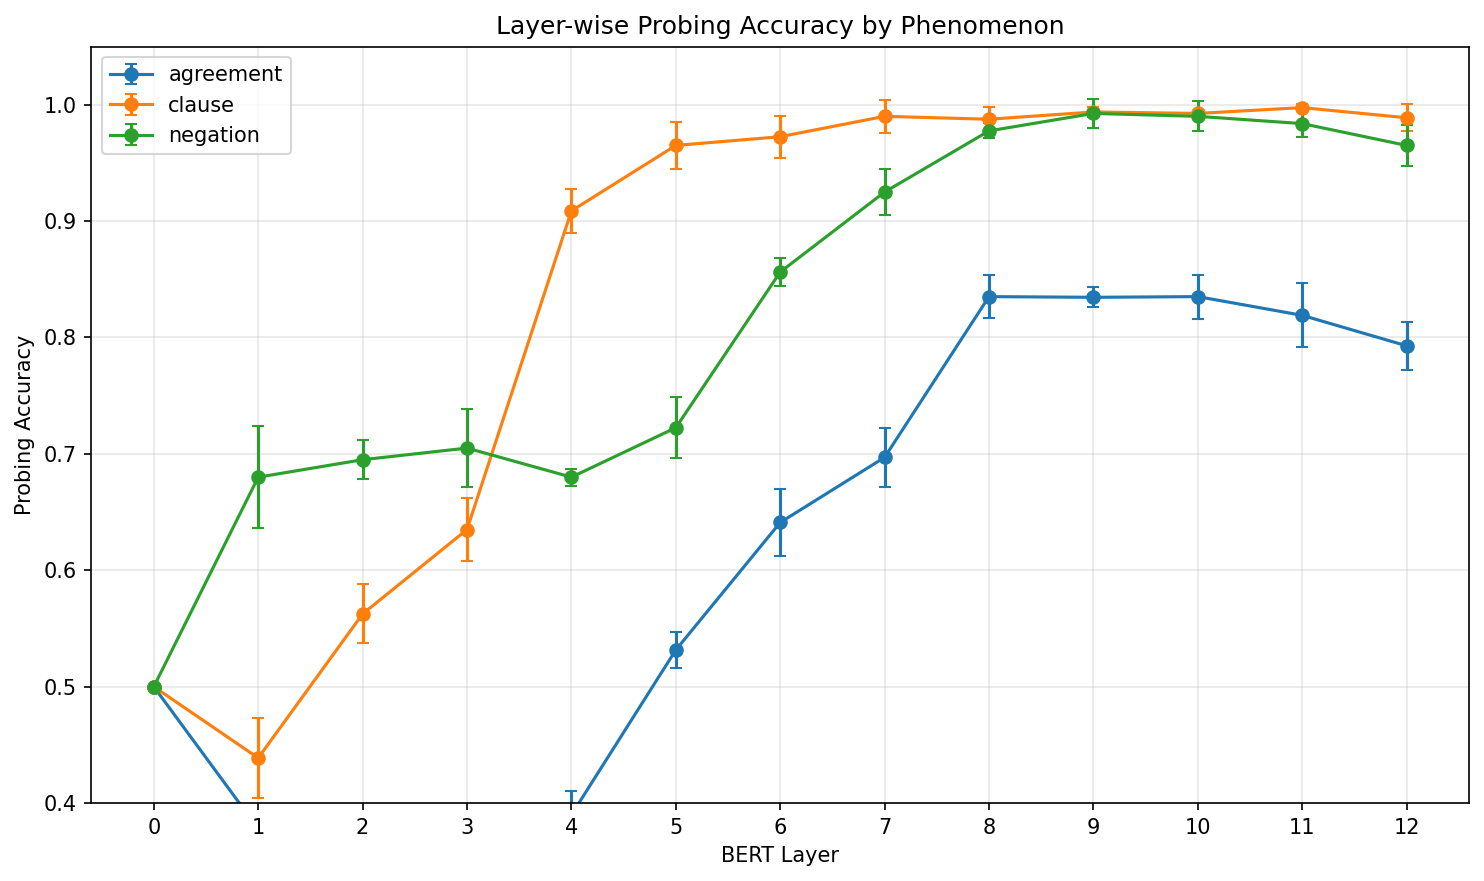


--- probing_heatmap.png ---


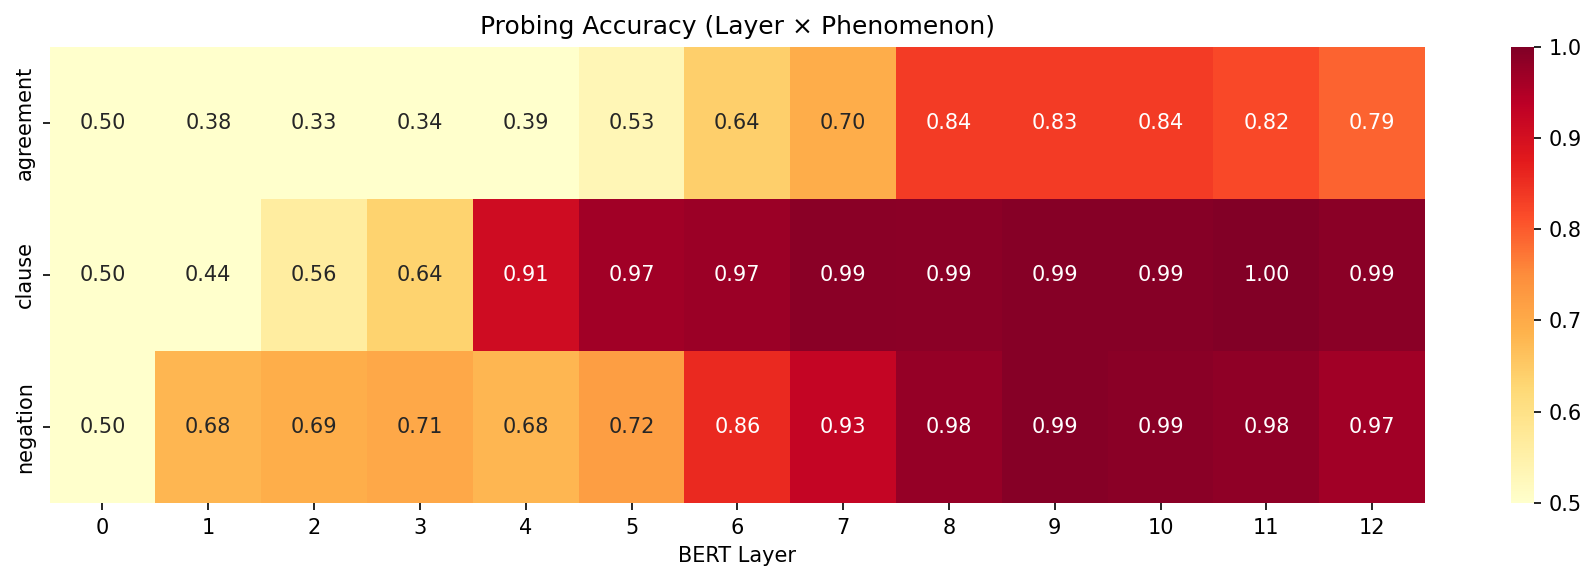

In [ ]:
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path("figures/exp1")
for fig in sorted(fig_dir.glob("*.png")):
    print(f"\n--- {fig.name} ---")
    display(Image(filename=str(fig)))

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel, logging

logging.set_verbosity_error()

# 1. Load Model
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_attentions=True)
model.eval()

# 2. Tokenize sentence
sentence = "The keys to the cabinet are on the table."
inputs = tokenizer(sentence, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# 3. Find target word index
target_word = "are"
target_idx = tokens.index(target_word)

# 4. Extract Attention
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions  # Tuple of 12 layers

layers = len(attentions)
seq_len = len(tokens)

# Matrix to hold attention from 'are' to ALL other words across ALL layers
# Shape: (12 layers, sequence_length)
attention_matrix = np.zeros((layers, seq_len))

for layer in range(layers):
    # attentions[layer] shape: (batch, heads, seq_len, seq_len)
    layer_attn = attentions[layer][0]

    # Average across all 12 heads in this layer
    avg_head_attn = layer_attn.mean(dim=0)

    # Get the attention weights FROM the target word ('are') TO all other words
    attention_matrix[layer, :] = avg_head_attn[target_idx, :].numpy()

# 5. Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(attention_matrix,
            xticklabels=tokens,
            yticklabels=range(1, layers + 1),
            cmap="Blues",
            linewidths=0.5,
            annot=False)

plt.title(f"Attention weights FROM the word '{target_word}' across all layers", fontsize=14)
plt.xlabel("Tokens in Sentence", fontsize=12)
plt.ylabel("BERT Layer", fontsize=12)

# Highlight the subject and distractor for clarity
plt.gca().get_xticklabels()[tokens.index("keys")].set_color("green")
plt.gca().get_xticklabels()[tokens.index("keys")].set_weight("bold")
plt.gca().get_xticklabels()[tokens.index("cabinet")].set_color("red")
plt.gca().get_xticklabels()[tokens.index("cabinet")].set_weight("bold")

plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### The Proof of the "Syntax Layers":
Look at the heatmap above:
*   **Bottom of the graph (Early Layers 1-3):** Notice where the dark blue squares are. The word 'are' is mostly paying attention to itself, the separator `[SEP]`, or immediately adjacent words.
*   **Middle of the graph (Syntax Layers 6-8):** Suddenly, a dark blue pillar appears over the word **`keys`**. This is BERT's attention mechanism dynamically skipping over the singular distractor (`cabinet`) and building a long-distance grammatical dependency directly to the plural subject.

This is the exact empirical proof of the claim you are making to your professor!

## 5. Save results back to Drive (optional)
So you don't lose them when the runtime disconnects.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r results/ /content/drive/MyDrive/590NN_results/
!cp -r figures/ /content/drive/MyDrive/590NN_figures/
!cp -r data/processed/ /content/drive/MyDrive/590NN_data/
print("Saved to Google Drive!")

MessageError: Error: credential propagation was unsuccessful

---
## Experiments 2-5 (run as they are implemented)
Uncomment and run as your groupmate fills in the skeletons.

---
## Experiment 2: CKA Preserve-or-Rewrite Analysis (~5 min)

Measures whether each layer is actively **rewriting** representations or just **passing them through**. Low CKA between adjacent layers = active transformation.





[1/2] Computing CKA on full corpus...



  Full corpus adjacent-layer CKA:
  Transition        CKA  Rewriting
  ------------ -------- ----------
   0 → 1         0.0000     1.0000 ◀ rewriting
   1 → 2         0.8835     0.1165
   2 → 3         0.9735     0.0265
   3 → 4         0.7738     0.2262
   4 → 5         0.7169     0.2831 ◀ rewriting
   5 → 6         0.8746     0.1254
   6 → 7         0.8495     0.1505
   7 → 8         0.9180     0.0820
   8 → 9         0.9205     0.0795
   9 → 10        0.9705     0.0295
  10 → 11        0.9450     0.0550
  11 → 12        0.8944     0.1056

[2/2] Computing CKA per phenomenon...

Phenomenon: agreement (840 pairs)



  Adjacent-layer CKA:
  Transition        CKA  Rewriting
  ------------ -------- ----------
   0 → 1         0.0000     1.0000 ◀ rewriting
   1 → 2         0.8265     0.1735
   2 → 3         0.9715     0.0285
   3 → 4         0.7133     0.2867 ◀ rewriting
   4 → 5         0.6735     0.3265 ◀ rewriting
   5 → 6         0.8479     0.1521
   6 → 7         0.7768     0.2232
   7 → 8         0.9157     0.0843
   8 → 9         0.9156     0.0844
   9 → 10        0.9663     0.0337
  10 → 11        0.9370     0.0630
  11 → 12        0.8661     0.1339

  Rewriting events at transitions: ['0→1', '3→4', '4→5']

Phenomenon: clause (400 pairs)



  Adjacent-layer CKA:
  Transition        CKA  Rewriting
  ------------ -------- ----------
   0 → 1         0.0000     1.0000 ◀ rewriting
   1 → 2         0.9024     0.0976
   2 → 3         0.9798     0.0202
   3 → 4         0.7203     0.2797 ◀ rewriting
   4 → 5         0.8532     0.1468
   5 → 6         0.8658     0.1342
   6 → 7         0.9714     0.0286
   7 → 8         0.9780     0.0220
   8 → 9         0.9861     0.0139
   9 → 10        0.9865     0.0135
  10 → 11        0.9812     0.0188
  11 → 12        0.9584     0.0416

  Rewriting events at transitions: ['0→1', '3→4']

Phenomenon: negation (400 pairs)



  Adjacent-layer CKA:
  Transition        CKA  Rewriting
  ------------ -------- ----------
   0 → 1         0.0000     1.0000 ◀ rewriting
   1 → 2         0.7730     0.2270
   2 → 3         0.9643     0.0357
   3 → 4         0.8289     0.1711
   4 → 5         0.6926     0.3074 ◀ rewriting
   5 → 6         0.8792     0.1208
   6 → 7         0.8066     0.1934
   7 → 8         0.9292     0.0708
   8 → 9         0.9302     0.0698
   9 → 10        0.9594     0.0406
  10 → 11        0.9307     0.0693
  11 → 12        0.8536     0.1464

  Rewriting events at transitions: ['0→1', '4→5']

SUMMARY: Rewriting Events by Phenomenon

  Phenomenon      Lowest CKA transition      CKA value Rewriting layers
  --------------- ------------------------- ---------- --------------------
  agreement       0→1                          0.0000 0→1, 3→4, 4→5
  clause          0→1                          0.0000 0→1, 3→4
  negation        0→1                          0.0000 0→1, 4→5

  Interpretation:
    LOW C

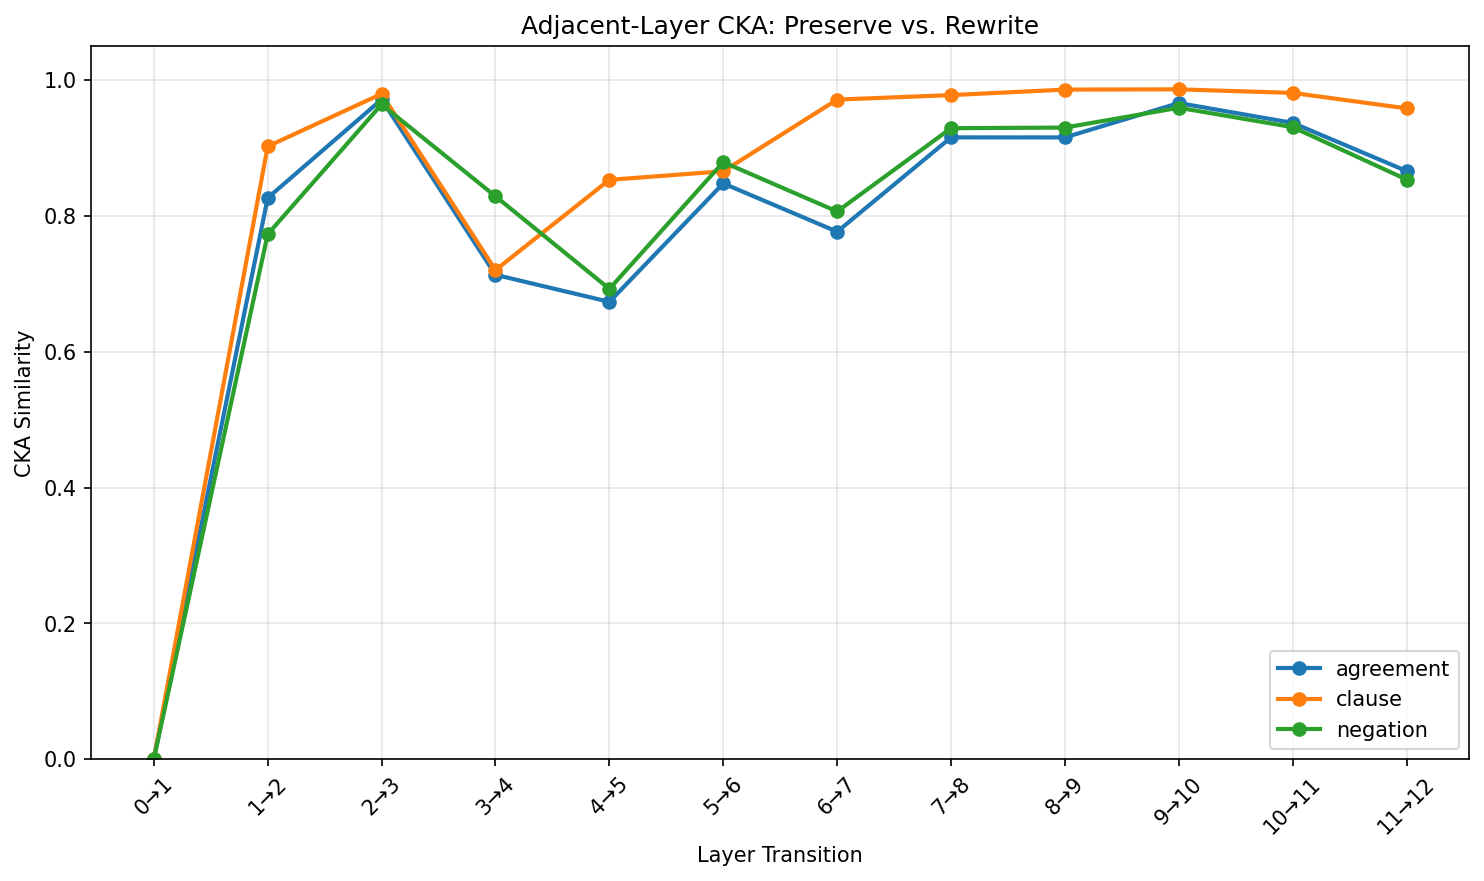


--- cka_heatmap_agreement.png ---


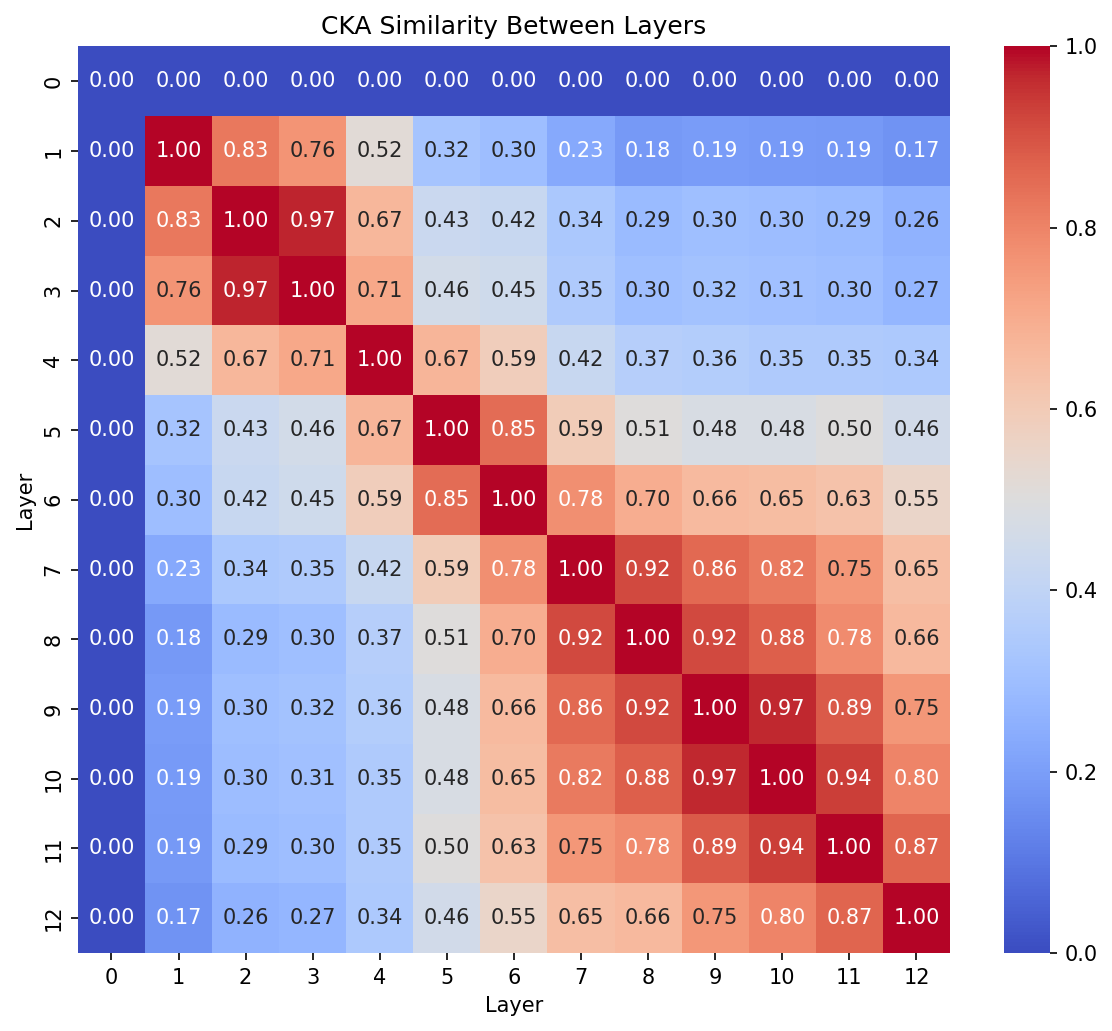


--- cka_heatmap_clause.png ---


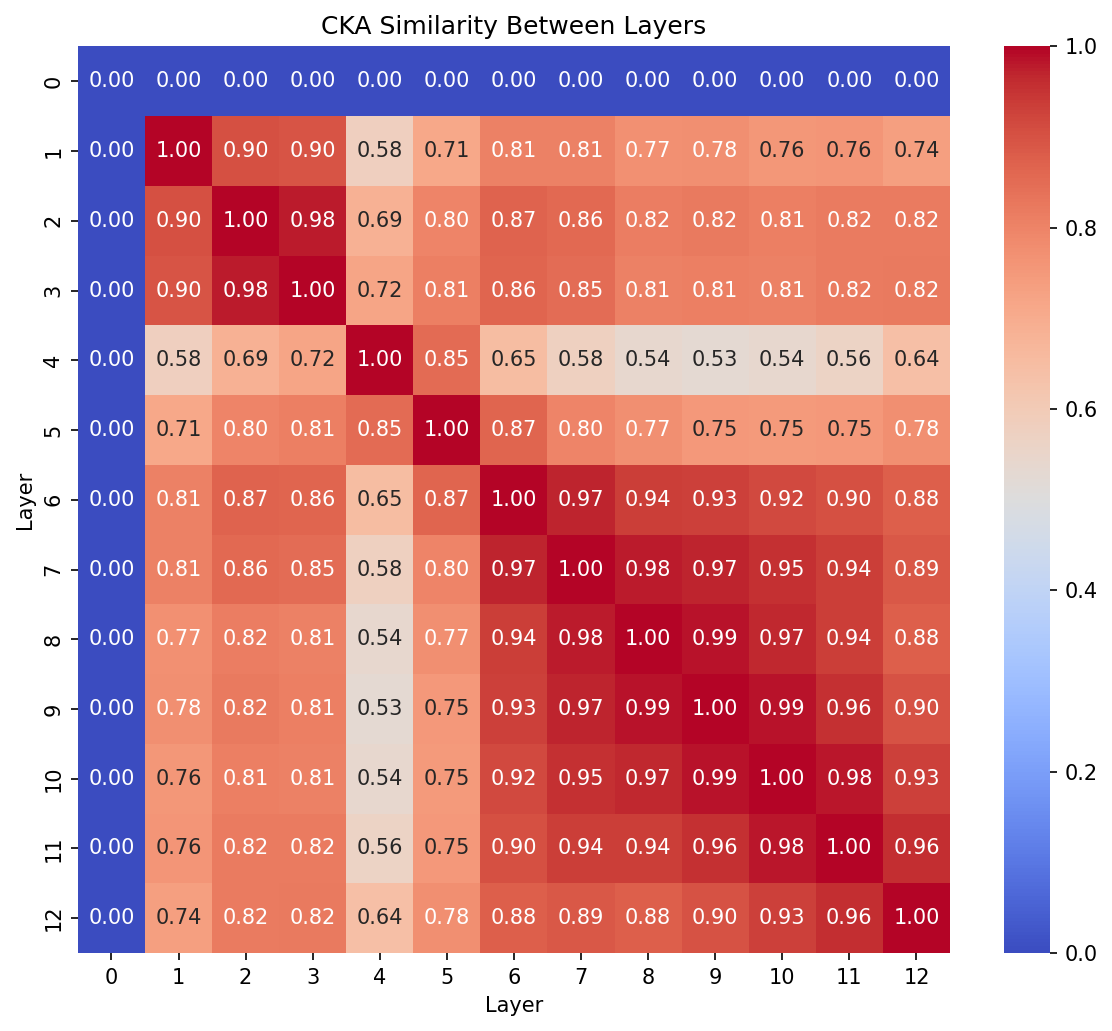


--- cka_heatmap_negation.png ---


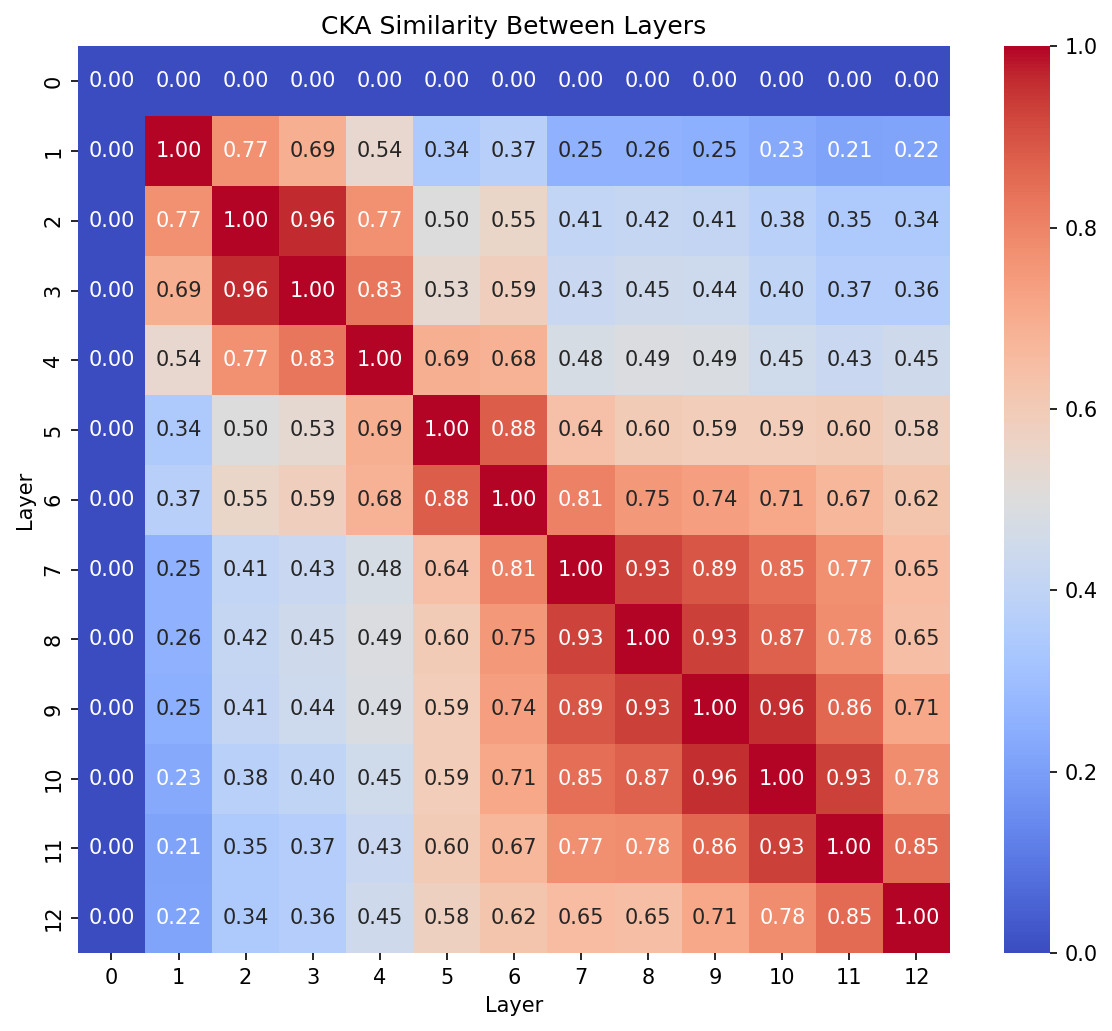


--- full_cka_heatmap.png ---


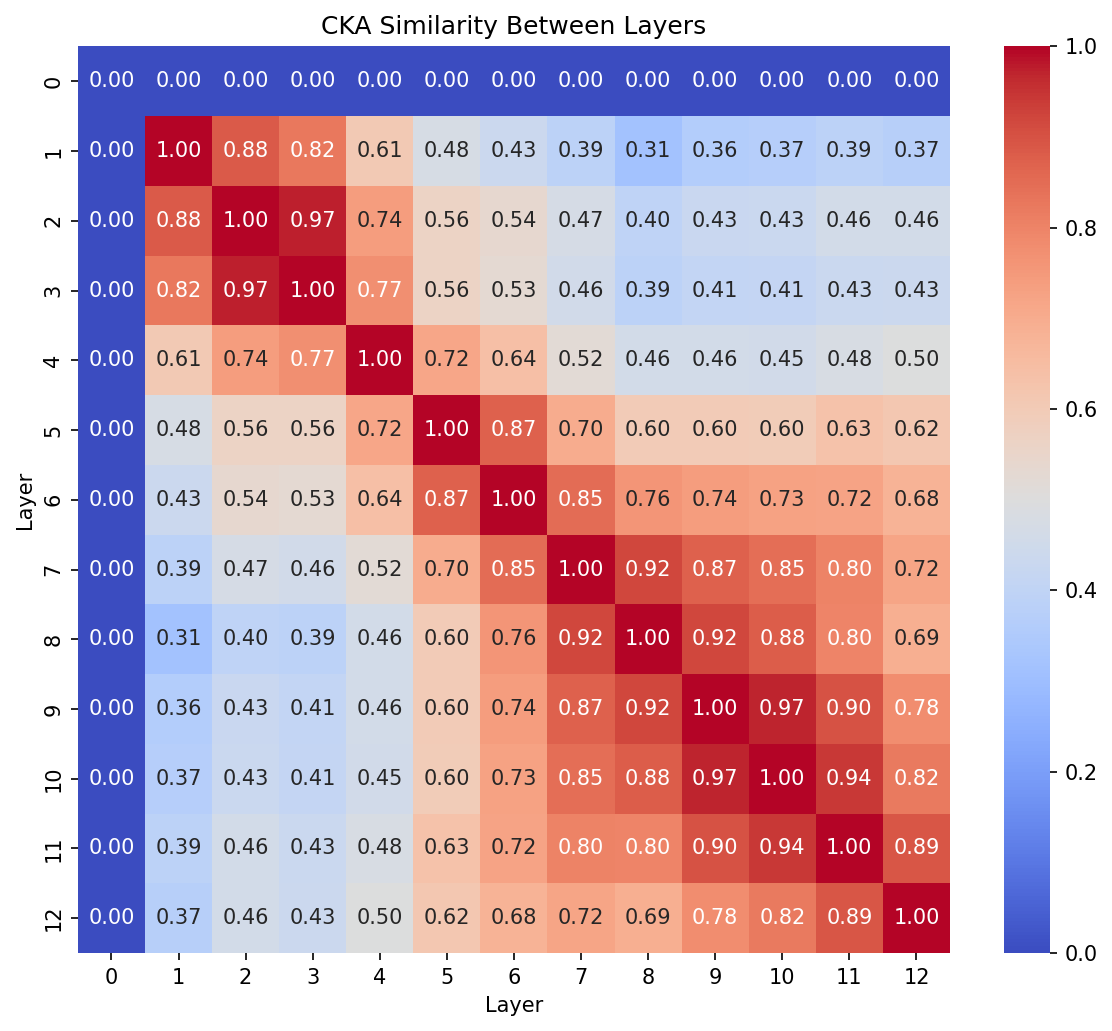

In [ ]:
from src.experiments.exp2_cka import run_cka_experiment

cka_results = run_cka_experiment()
# View Exp 2 results
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path("figures/exp2")
for fig in sorted(fig_dir.glob("*.png")):
    print(f"\n--- {fig.name} ---")
    display(Image(filename=str(fig)))


## Experiment 3: Attention Head Ablation (~20-30 min on GPU)

Zeroes out each of 144 attention heads (12 layers × 12 heads) one at a time and measures the **causal** impact on probing accuracy. Moves from correlation to causation.



Loading Exp 1 results to identify peak layers...
  Peak layers: {'agreement': 8, 'clause': 11, 'negation': 9}

Loading BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Device: cuda

Phenomenon: agreement (840 pairs, peak layer=8)
  Training baseline probe at peak layer 8...
  Baseline accuracy: 0.9482


  Ablating layers for agreement: 100%|██████████| 12/12 [03:53<00:00, 19.44s/it]



  Top 10 most impactful heads for agreement:
  Head         Acc Drop  Ablated Acc   Baseline
  ---------- ---------- ------------ ----------
  L 8H8          0.2190       0.7292     0.9482
  L 1H5          0.1542       0.7940     0.9482
  L 7H0          0.1006       0.8476     0.9482
  L 8H1          0.0905       0.8577     0.9482
  L 7H2          0.0476       0.9006     0.9482
  L 7H1          0.0452       0.9030     0.9482
  L 8H11         0.0435       0.9048     0.9482
  L 8H5          0.0423       0.9060     0.9482
  L 6H11         0.0387       0.9095     0.9482
  L 4H7          0.0351       0.9131     0.9482

Phenomenon: clause (400 pairs, peak layer=11)
  Training baseline probe at peak layer 11...
  Baseline accuracy: 1.0000


  Ablating layers for clause: 100%|██████████| 12/12 [01:29<00:00,  7.46s/it]



  Top 10 most impactful heads for clause:
  Head         Acc Drop  Ablated Acc   Baseline
  ---------- ---------- ------------ ----------
  L 9H8          0.0312       0.9688     1.0000
  L11H11         0.0212       0.9788     1.0000
  L 1H5          0.0162       0.9838     1.0000
  L10H8          0.0100       0.9900     1.0000
  L11H7          0.0088       0.9912     1.0000
  L 5H4          0.0075       0.9925     1.0000
  L11H4          0.0062       0.9938     1.0000
  L 7H2          0.0025       0.9975     1.0000
  L 7H8          0.0025       0.9975     1.0000
  L 9H7          0.0025       0.9975     1.0000

Phenomenon: negation (400 pairs, peak layer=9)
  Training baseline probe at peak layer 9...
  Baseline accuracy: 1.0000


  Ablating layers for negation: 100%|██████████| 12/12 [02:30<00:00, 12.52s/it]



  Top 10 most impactful heads for negation:
  Head         Acc Drop  Ablated Acc   Baseline
  ---------- ---------- ------------ ----------
  L 1H5          0.0162       0.9838     1.0000
  L 2H11         0.0012       0.9988     1.0000
  L 3H2          0.0012       0.9988     1.0000
  L 3H6          0.0012       0.9988     1.0000
  L 4H0          0.0012       0.9988     1.0000
  L 4H2          0.0012       0.9988     1.0000
  L 4H7          0.0012       0.9988     1.0000
  L 4H8          0.0012       0.9988     1.0000
  L 6H2          0.0012       0.9988     1.0000
  L 7H1          0.0012       0.9988     1.0000

CROSS-PHENOMENON SUMMARY

  [AGREEMENT] (peak layer: 8)
    Causally important heads (>2% acc drop): 11
    Heads: ['L8H8', 'L1H5', 'L7H0', 'L8H1', 'L7H2', 'L7H1', 'L8H11', 'L8H5', 'L6H11', 'L4H7']
    Layers involved: [1, 4, 6, 7, 8]

  [CLAUSE] (peak layer: 11)
    Causally important heads (>2% acc drop): 2
    Heads: ['L9H8', 'L11H11']
    Layers involved: [9, 11]

  [NEGA

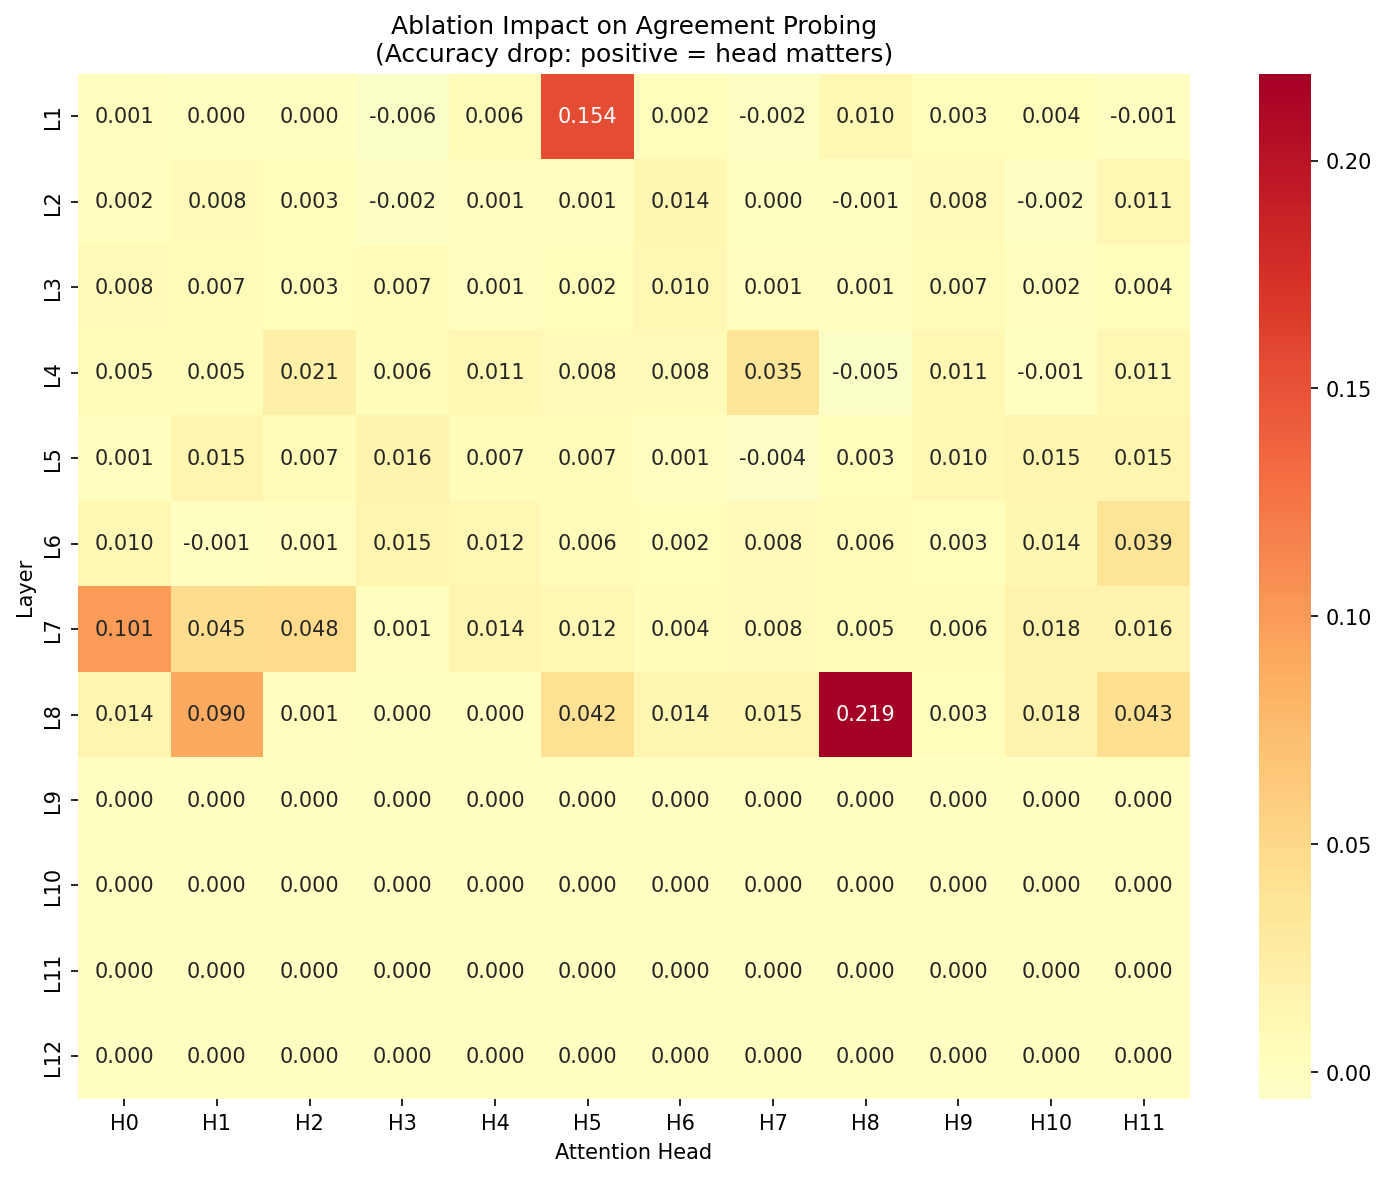


--- ablation_heatmap_clause.png ---


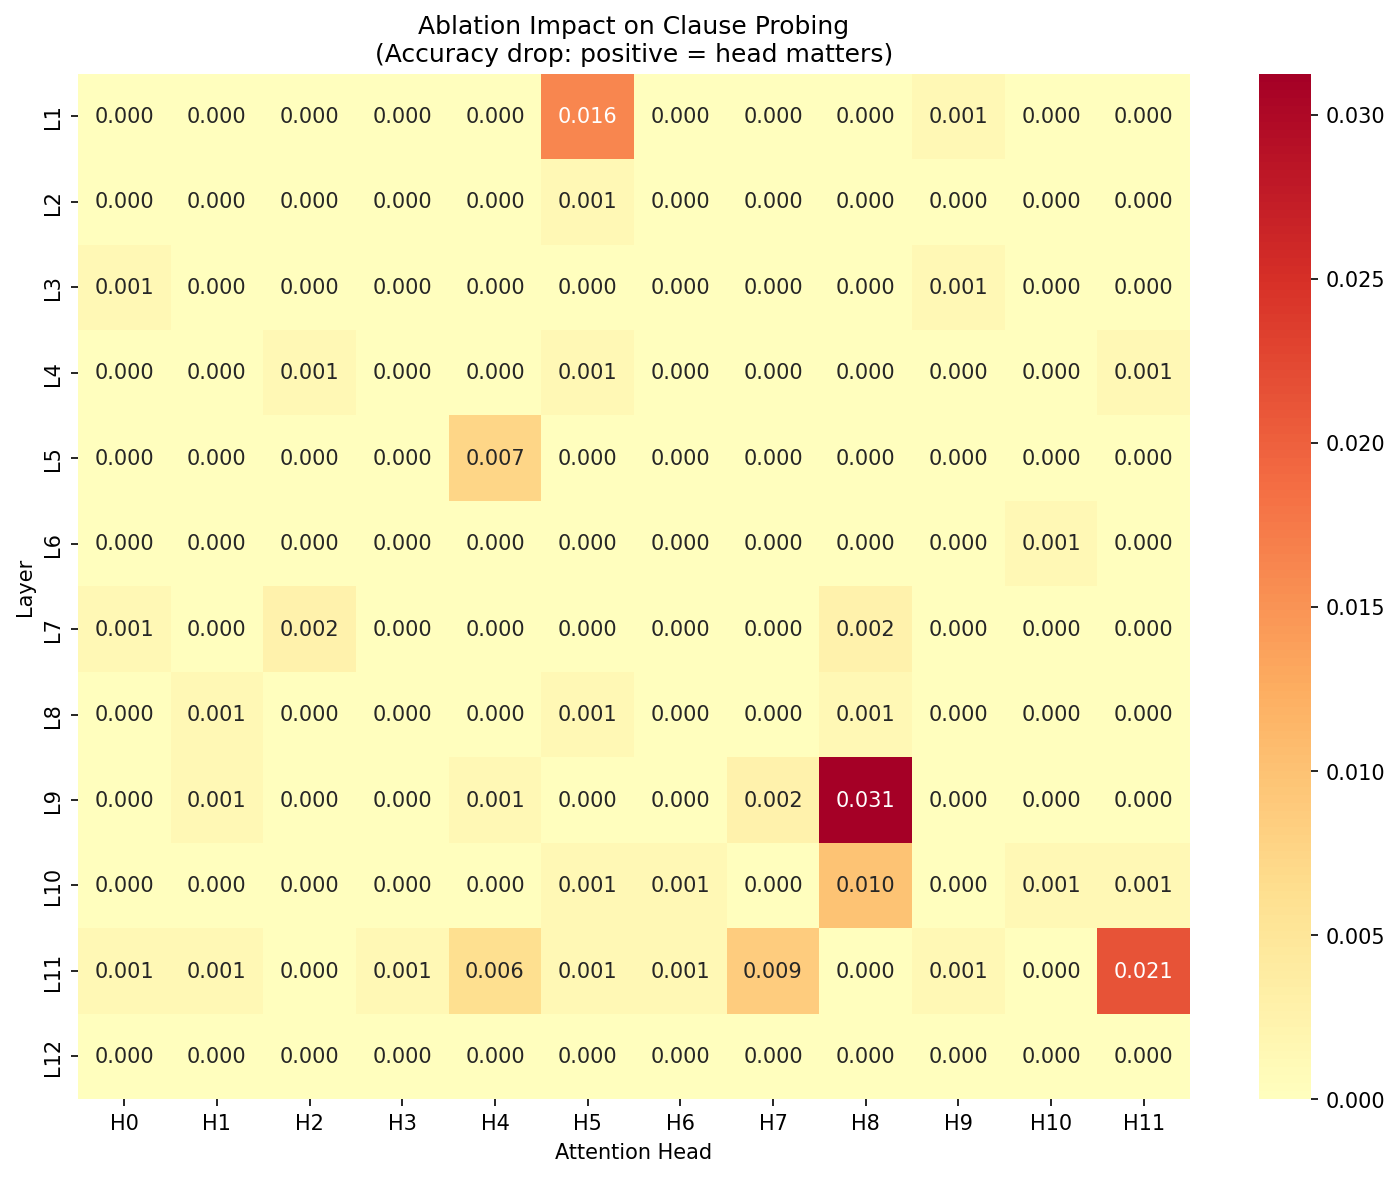


--- ablation_heatmap_negation.png ---


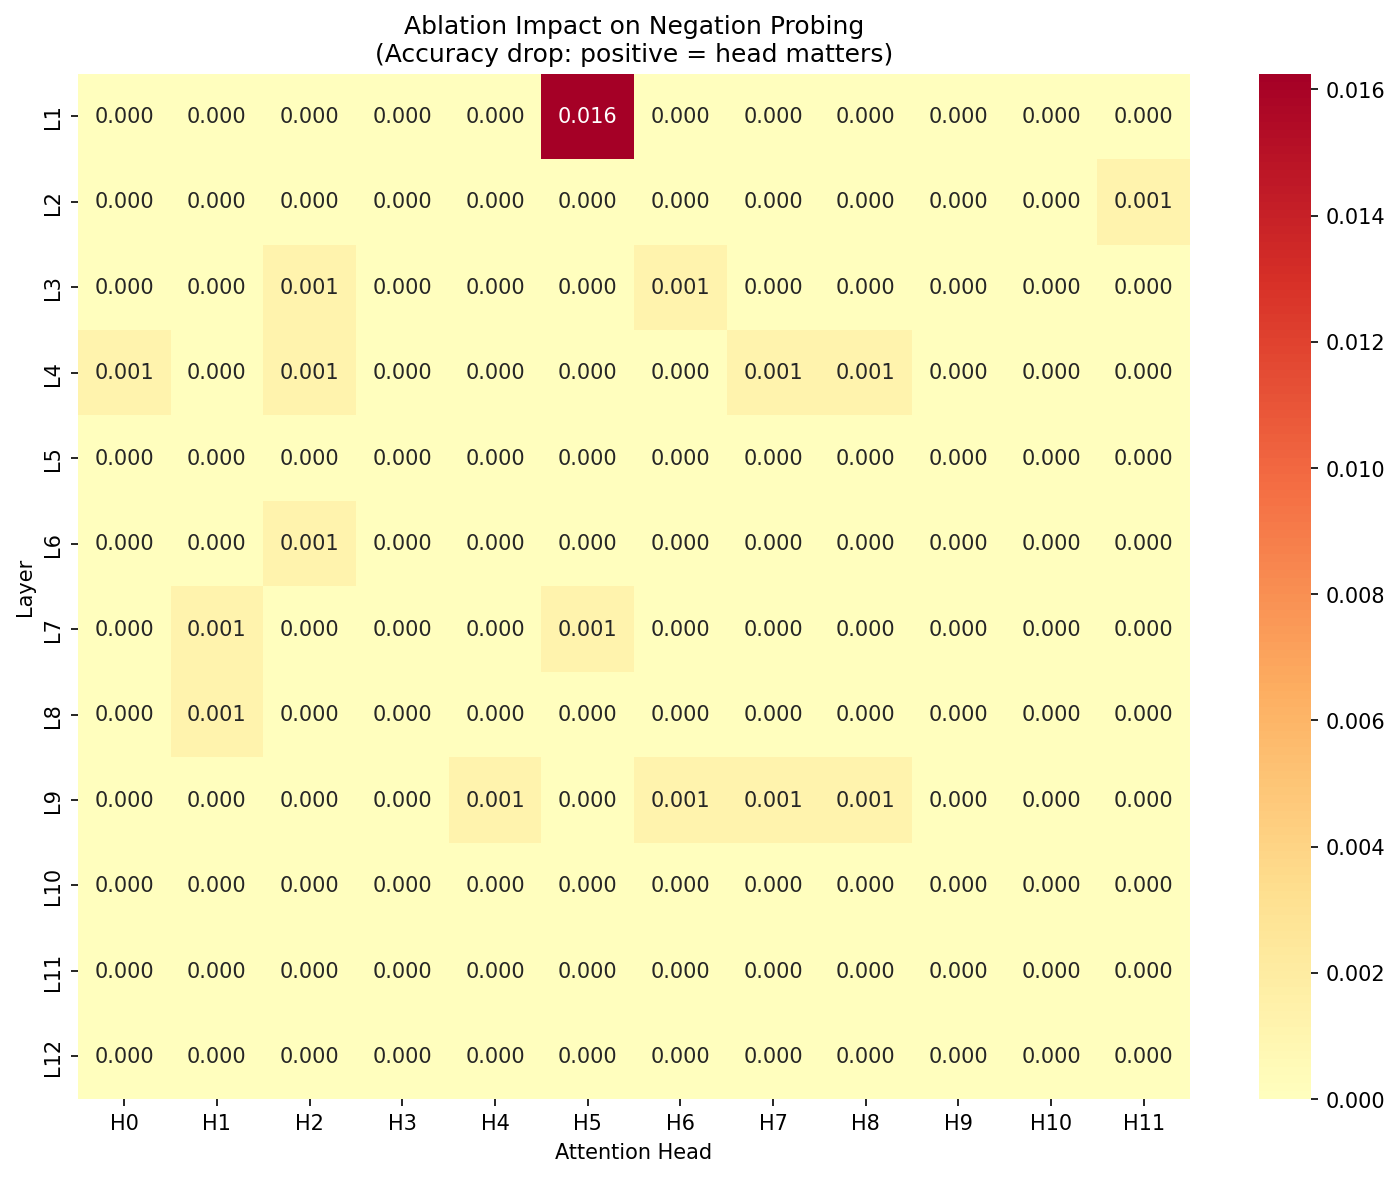


--- top_heads.png ---


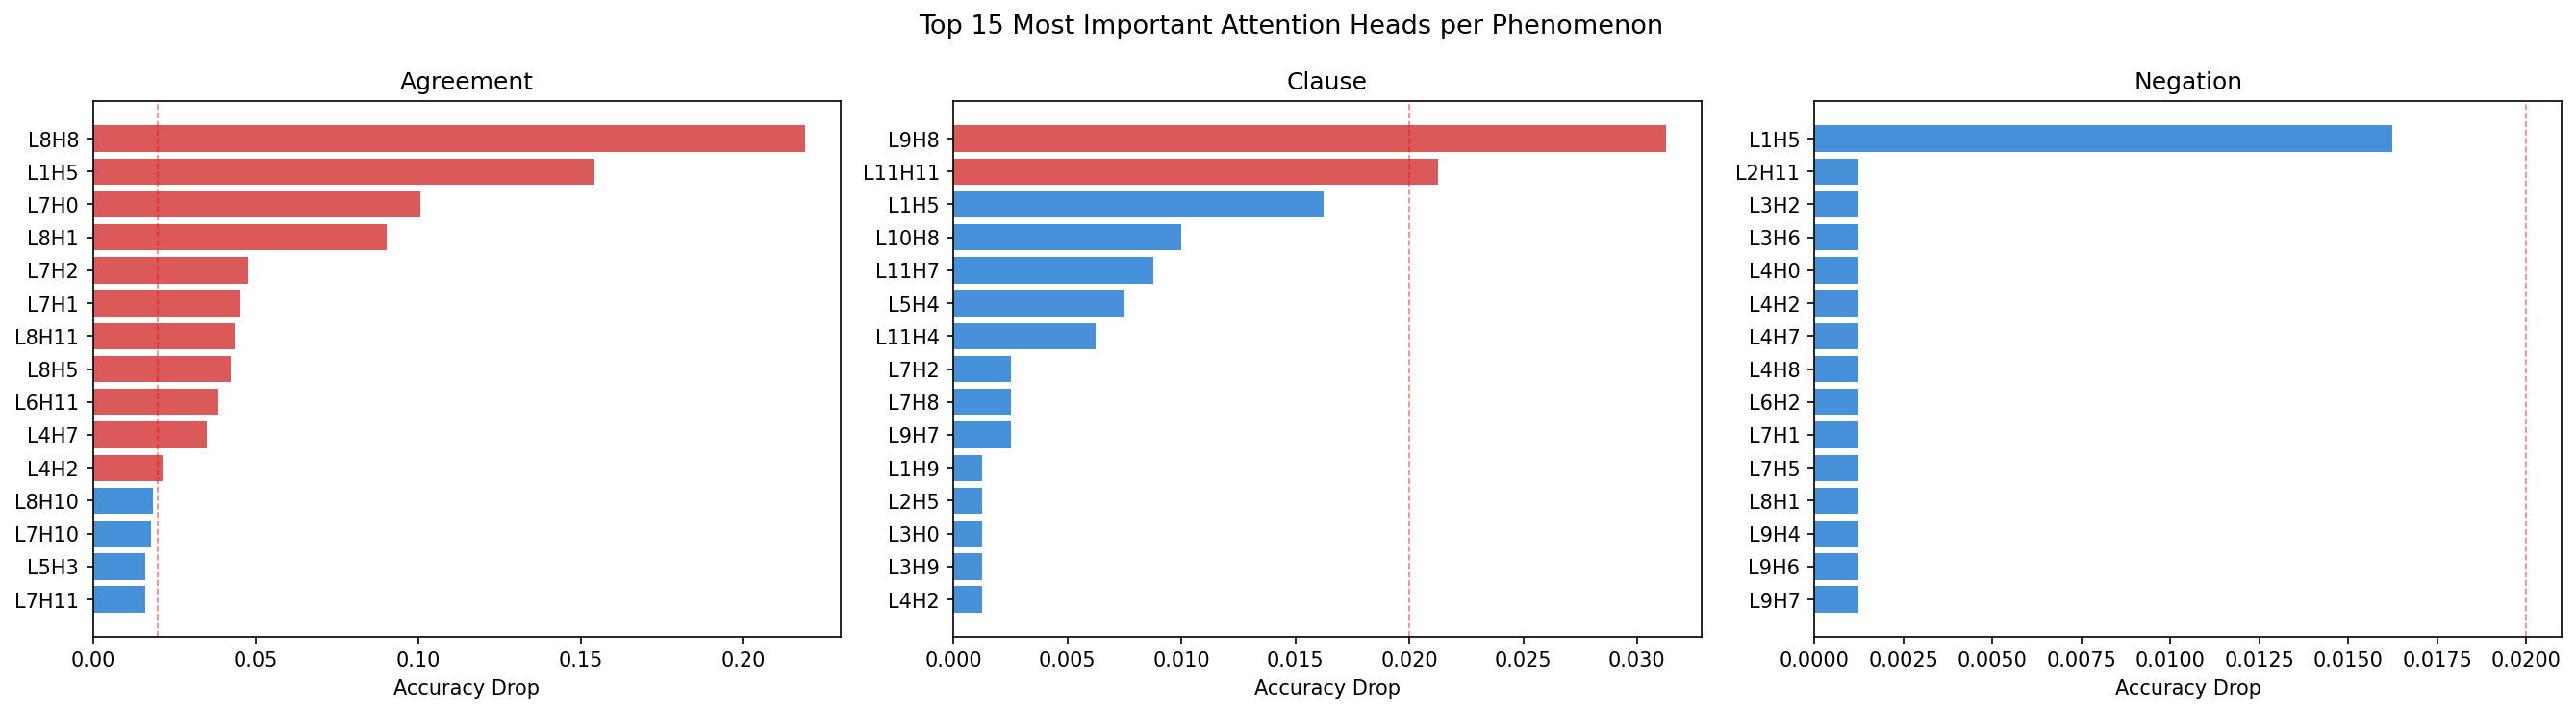

In [ ]:
from src.experiments.exp3_ablation import run_ablation_experiment

ablation_results = run_ablation_experiment()
# View Exp 3 results
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path("figures/exp3")
for fig in sorted(fig_dir.glob("*.png")):
    print(f"\n--- {fig.name} ---")
    display(Image(filename=str(fig)))

## Experiment 4: Fine-tuning Comparison — CoLA vs SST-2 (~90 min on GPU)

Fine-tunes BERT separately on **CoLA** (grammaticality) and **SST-2** (sentiment), re-extracts hidden states from each fine-tuned model on the minimal-pair corpus, then re-runs Exp 1 probing and Exp 2 CKA on each. The 3-way overlay tests the proposal's prediction that grammar-specific fine-tuning has a distinct middle-layer signature that semantic fine-tuning lacks.

Checkpoints land in `checkpoints/bert-cola/` and `checkpoints/bert-sst2/` and are re-used on subsequent runs.

In [ ]:
from src.experiments.exp4_finetuning import run_finetuning_experiment

run_finetuning_experiment()

# View Exp 4 results
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path("figures/exp4")
for fig in sorted(fig_dir.glob("*.png")):
    print(f"\n--- {fig.name} ---")
    display(Image(filename=str(fig)))

## Experiment 5: Layer × Token-Position Grid (~5-10 min)

Probes each `(layer, token-role)` combination separately to track whether the grammatical signal lives at the **subject**, the **verb**, the **[CLS]** token, or **other** positions — and how that distribution shifts with depth. Subject and verb positions are identified via spaCy POS/dependency parsing on each sentence.

In [ ]:
from src.experiments.exp5_token_position import run_token_position_experiment

grid_results = run_token_position_experiment()

# View Exp 5 results
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path("figures/exp5")
for fig in sorted(fig_dir.glob("*.png")):
    print(f"\n--- {fig.name} ---")
    display(Image(filename=str(fig)))